In [2]:
import pandas as pd
import numpy as np
import re
from scipy.stats import linregress
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import linregress,pearsonr,spearmanr
from scipy.optimize import curve_fit
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import re
from statsmodels.stats.multitest import multipletests
import pingouin as pg
scaler = StandardScaler()
from collections import defaultdict

plt.rcParams["font.family"] = "Helvetica Neue"

In [3]:
def mod_hyperbolic_model(r, a, b, rmin):
    return a / (r - rmin) + b

def plot_and_fit_curve(ax, df, x_col, y_col, label, color, plot=False, fixed_rmin=None, **kwargs):

    xs = df[x_col].values
    ys = df[y_col].values
    norm = False
    if norm:
        fv = np.mean(ys[-10:])
    else:
        fv = 1

    if plot:
        ax.scatter(xs, ys / fv, edgecolor='none', color=color, **kwargs)
    label = label.replace("non-smokers", "N").replace("smokers", "S")

    a_bounds = (-np.inf, np.inf)
    b_bounds = (-1e-3, np.inf)

    try:
        if fixed_rmin is not None:
            def model_fixed(r, a, b):
                return a / (r - fixed_rmin) + b

            popt, _ = curve_fit(
                model_fixed, xs, ys,
                p0=[1.0, np.min(ys)],
                bounds=([a_bounds[0], b_bounds[0]], 
                        [a_bounds[1], b_bounds[1]]),
                maxfev=5000
            )
            a_fit, b_fit = popt
            rmin_fit = fixed_rmin
            popt = (a_fit, b_fit, rmin_fit)
        else:
            rmin_upper_bound = np.min(xs) * 0.95
            r_bounds = (0.3, rmin_upper_bound)

            popt, _ = curve_fit(
                mod_hyperbolic_model, xs, ys,
                p0=[1.0, np.min(ys), 0.5],
                bounds=([a_bounds[0], b_bounds[0], r_bounds[0]], 
                        [a_bounds[1], b_bounds[1], r_bounds[1]]),
                maxfev=5000
            )
            a_fit, b_fit, rmin_fit = popt

        y_predicted = mod_hyperbolic_model(xs, *popt)
        residuals = ys - y_predicted
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((ys - np.mean(ys))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        rmse = np.sqrt(np.mean(residuals**2))
        ner_frac = b_fit / np.mean(ys)

        if plot:
            print(
                f"Fit for {y_col} ({label}): a={a_fit:.2f}, b={b_fit:.2f}, "
                f"r*={rmin_fit:.2f}, R2={r_squared:.2f}, "
                f"mean(y)={np.mean(ys):.2f}, NER_frac={ner_frac:.2f}"
            )

        if plot:
            xmin, xmax = np.min(xs), np.max(xs)
            xmin = xmin * 0.975 if xmin >= rmin_fit else xmin
            x_curve = np.linspace(xmin, xmax, 500)
            y_curve = mod_hyperbolic_model(x_curve, *popt)
            ax.plot(x_curve, y_curve / fv, color=color, label=f"{label}: R$^{2}$={r_squared:.2f}", lw=2,
                    ls="--" if "(N" in label else "-", alpha=0.8)

            ax.set_xlim([xmin, xmax])
            ax.set_xlabel("Repair rate (day$^{-1}$)")

            if norm:
                ax.set_ylabel("Fold mutation rate relative to high repair regions")
            else:
                lab_d = "clustered" if "cluster" in y_col else y_col[1:]
                ax.set_ylabel(f"Average number of {lab_d} mutations")
            ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

        return {"params": popt, "r2": r_squared, "rmse": rmse}

    except RuntimeError:
        print(f"Could not fit curve for {y_col} ({label}).")
        return None


In [4]:
import session_info
session_info.show()

Cell type palette and info

In [5]:
palette = {"neurons":"C0", 
           "glia":"C1", 
           "oligo":"C1",
           "maternal":"C2", 
           "paternal":"C3", 
           "lung":"C6", 
           "liver":"C9"}

pd.read_table("numbers-used-along-repair.tab").groupby("Tissue_CellType").size()

Tissue_CellType
Liver_never-smoker     433
Liver_smoker          1152
Lung_never-smoker      256
Lung_smoker            376
Neuron                  56
Oligo                   86
father                 451
mother                 451
dtype: int64

A and B bootstrapping

In [6]:
ng = pd.read_table("../data/Ng2021/Ng2021-signet-smokers-bootstrap-along-repair.tab")
ng_clust = pd.read_table("../data/Ng2021/Ng2021-signet-smokers-bootstrap-clusters-along-repair.tab")
ngns = pd.read_table("../data/Ng2021/Ng2021-signet-nonsmokers-bootstrap-along-repair.tab")
yos = pd.read_table("../data/Yoshida2020/Yoshida2020-signet-smokers-bootstrap-along-repair.tab")
yos_clust = pd.read_table("../data/Yoshida2020/Yoshida2020-signet-smokers-bootstrap-clusters-along-repair.tab")
yosns = pd.read_table("../data/Yoshida2020/Yoshida2020-signet-nonsmokers-bootstrap-along-repair.tab")
colon = pd.read_table("../data/Olafsson2020/Olafsson2020-signet-bootstrap-along-repair.tab")
neurons = pd.read_table("../data/Ganz2024/Ganz2024-signet-neurons-bootstrap-along-repair.tab")
glia = pd.read_table("../data/Ganz2024/Ganz2024-signet-glia-bootstrap-along-repair.tab")
maternal = pd.read_table("../data/Germline/Germline-signet-maternal-bootstrap-along-repair50.tab")
paternal = pd.read_table("../data/Germline/Germline-signet-paternal-bootstrap-along-repair50.tab")

yos_clust.columns = list(yos_clust.columns[:2]) + [f"nClusters_{i}" if i>0 else "nClusters" for i,c in enumerate(yos_clust.columns[2:])]
ng_clust.columns = list(ng_clust.columns[:2]) + [f"nClusters_{i}" if i>0 else "nClusters" for i,c in enumerate(ng_clust.columns[2:])]
yos = pd.concat([yos, yos_clust[[c for c in yos_clust.columns if "Clust" in c]]], axis=1)
ng = pd.concat([ng, ng_clust[[c for c in ng_clust.columns if "Clust" in c]]], axis=1)

neu_repair = pd.read_csv("neurons_sar-repairseq.csv")
gli_repair = pd.read_csv("oligo_sar-repairseq.csv")
peaks_repair = pd.read_csv("peaks.csv")

n_indivs = {"Liver_smoker": [ng, 1152], 
            "Liver_clusters": [ng_clust, 1152],
            "Liver_nonsmoker": [ngns, 433],
            "Lung_smoker": [yos, 376], 
            "Lung_clusters": [yos_clust, 376], 
            "Lung_nonsmoker": [yosns, 256], 
            "Neuron": [neurons, 56], 
            "Glia": [glia, 86],
            "Paternal": [paternal, 451],
            "Maternal": [maternal, 451], 
            "Intestine":[colon, 897]}

sigs = [c for c in yos.columns if c.startswith("nSBS") or c.startswith("nCluster")]

for k,v in n_indivs.items():
    df = v[0]
    for sig in sigs:
        if sig not in df.columns: continue
        df[sig] = df[sig] / v[1]
        if k not in ["Paternal", "Maternal"]: # bring to haploid genome
            df[sig] = df[sig] / 2
        if k in ["Paternal", "Maternal"]: # account for 50-tiles
            df[sig] = df[sig] / 2
    df["RepairRate"] = df["RepairRate"] * 1440

In [7]:
config = {
    "Liver_smoker": [ng, ["SBS4", "SBS5", "Clusters"]],
    "Liver_nonsmoker": [ngns, ["SBS5"]],            
    "Lung_smoker": [yos, ["SBS4", "SBS5", "Clusters"]],  
    "Lung_nonsmoker": [yosns, ["SBS5"]],
    "Neuron": [neurons, ["SBS5"]], 
    "Glia": [glia, ["SBS5"]],
    "Paternal": [paternal, ["SBS5"]],
    "Maternal": [maternal, ["SBS5"]], 
    "Intestine":[colon, ["SBS5"]]
    }

res_l = []
cis = {}
fixed_rmin = 0.55
boot_params = {}  # store raw bootstrap samples

for ctype, (df, sigs) in config.items():
    for sig in sigs:
        a_s, b_s, r_s = [], [], []
        for boot in range(1, 1001):
            res = plot_and_fit_curve(None, df, "RepairRate", f"n{sig}_{boot}", ctype, None, fixed_rmin=fixed_rmin, plot=False)
            if res is None: continue
            a, b, r_star = res["params"]
            a_s.append(a)
            b_s.append(b)
            r_s.append(r_star)  

        res = plot_and_fit_curve(None, df, "RepairRate", f"n{sig}", ctype, None, fixed_rmin=fixed_rmin, plot=False)
        a, b, r = res["params"]

        a_low, a_high = np.percentile(a_s, 2.5), np.percentile(a_s, 97.5)
        b_low, b_high = np.percentile(b_s, 2.5), np.percentile(b_s, 97.5)
        res_l.append([a, a_low, a_high, ctype, sig, "A"])
        res_l.append([b, b_low, b_high, ctype, sig, "B"])

        cis[(ctype, sig)] = {
            "A": [a_low, a, a_high],
            "B": [b_low, b, b_high],
            "R": [np.percentile(r_s, 2.5), r, np.percentile(r_s, 97.5)],
        }
        # store raw samples as (n_bootstrap, 3) array
        boot_params[(ctype, sig)] = np.column_stack([a_s, b_s, r_s])

ab_boot = pd.DataFrame(res_l)
ab_boot.columns = ["point", "low", "high", "ctype", "sig", "param"]

In [8]:
def plot_curve(ax, key, sig, color, label, boot_params, cis, n_indivs, r2=None, **kwargs):
    df = n_indivs[key][0]
    xs = df["RepairRate"].values
    popt = tuple(cis[(key, sig)][p][1] for p in "ABR")

    xmin, xmax = np.min(xs), np.max(xs)
    xmin = xmin * 0.975 if xmin >= popt[2] else xmin
    x_curve = np.linspace(xmin, xmax, 500)

    all_curves = np.array([mod_hyperbolic_model(x_curve, *p) for p in boot_params[(key, sig)]])
    y_curve  = mod_hyperbolic_model(x_curve, *popt)
    y_lower  = np.percentile(all_curves, 2.5,  axis=0)
    y_upper  = np.percentile(all_curves, 97.5, axis=0)

    ls = "--" if "non" in key else "-"
    ax.plot(x_curve, y_curve, color=color, lw=2, alpha=0.8)
    ax.fill_between(x_curve, y_lower, y_upper, color=color, alpha=0.15)

    df = n_indivs[key][0]
    xs = df["RepairRate"].values
    ys = df[f"n{sig}"].values
    ax.scatter(xs, ys, edgecolor='none', color=color, label=label, **kwargs) #, 

    ax.set_xlim([xmin, xmax])

In [9]:
ab_boot["ctype"] = ab_boot.ctype.str.replace("_smoker", " (S)")
ab_boot["ctype"] = ab_boot.ctype.str.replace("_nonsmoker", " (NS)")

<ipython-input-8-fcf500498808>:22: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(xs, ys, edgecolor='none', color=color, label=label, **kwargs) #,


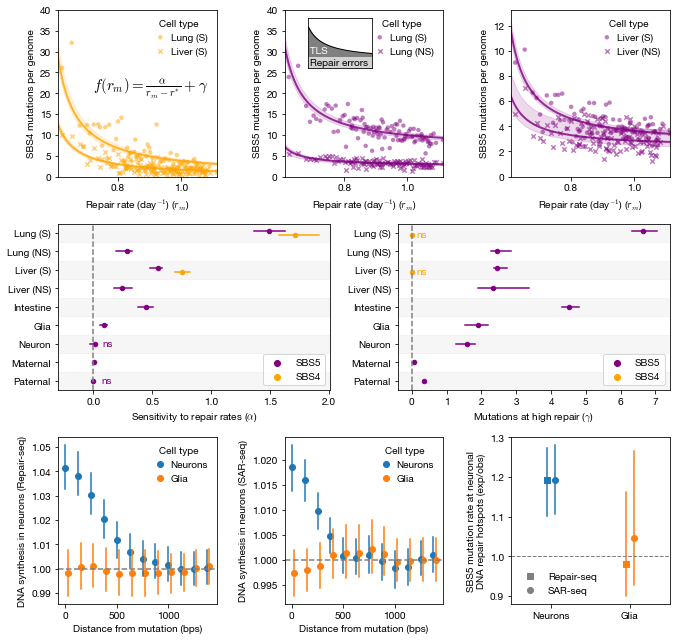

In [10]:
plt.rcParams["font.family"] = "Helvetica Neue"
mosaic = '''
AABBGG
CCCDDD
EEFFII
'''
fig, axs = plt.subplot_mosaic(mosaic, figsize=[9.5,9])

sz = 20
ap = 0.5
pal = {"S":"C0", "NS":"C1"}
sig_pal = {"SBS5":"purple", "SBS4":"orange", "Clusters":"C2"}

### Curve SBS4 ###
ax = axs["A"]
plot_curve(ax, "Lung_smoker", "SBS4", sig_pal["SBS4"], "Lung (S)", boot_params, cis, n_indivs, s=sz, alpha=ap)
plot_curve(ax, "Liver_smoker", "SBS4", sig_pal["SBS4"], "Liver (S)", boot_params, cis, n_indivs, s=sz, alpha=ap, marker="x")
ax.legend(frameon=False, loc="upper right", title="Cell type", handletextpad=0.05, borderpad=0.4, labelspacing=0.5) #bbox_to_anchor=(1.02, 0.7),

# \mathrm{min} makes 'min' upright, which looks much cleaner
formula = r'$f(r_m) = \frac{\alpha}{r_m - r^{*}} + \gamma$'

axs["A"].text(0.95, 0.6, formula, 
              transform=axs["A"].transAxes, 
              fontsize=15, ha="right", va="top",
              math_fontfamily='cm') # 'cm' stands for Computer Modern (LaTeX font)

ax.set_ylim([0, 40])
ax.set_xlim(left=0.61)
ax.set_xlabel(r"Repair rate (day$^{-1}$) ($r_m$)", math_fontfamily='cm')
ax.set_ylabel("SBS4 mutations per genome")

### Curves SBS5 ###
ax = axs["B"]
plot_curve(ax, "Lung_smoker", "SBS5", sig_pal["SBS5"], "Lung (S)", boot_params, cis, n_indivs, s=sz, alpha=ap)
plot_curve(ax, "Lung_nonsmoker", "SBS5", sig_pal["SBS5"], "Lung (NS)", boot_params, cis, n_indivs, s=sz, marker="x", alpha=ap)
ax.legend(frameon=False, loc="upper right", title="Cell type", handletextpad=0.05, borderpad=0.4, labelspacing=0.5)
ax.set_xlim(left=0.61)
ax.set_ylim([0, 40])
ax.set_xlabel(r"Repair rate (day$^{-1}$) ($r_m$)", math_fontfamily='cm')
ax.set_ylabel("SBS5 mutations per genome")

### Inset
inset_ax = ax.inset_axes([0.15, 0.65, 0.4, 0.3]) # [x, y, width, height]
minx = yos.RepairRate.min()
maxx = yos.RepairRate.max()
s = 4.88
b = 9.77
rmin = 0.50

xs = np.linspace(minx, maxx, 500)
ys = s / (xs - rmin) + b
inset_ax.plot(xs, ys, lw=1, color="black")

inset_ax.fill_between(xs, ys, where=(ys > b),
                      color='gray', label='TLS')
inset_ax.fill_between(xs, 14,
                      color='lightgray', label='NER')

inset_ax.set_xlabel("", fontsize=8)
inset_ax.set_ylabel("", fontsize=8)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.annotate("Repair errors", xy=(0.03, 0.12), color="black",
                  xycoords="axes fraction", ha="left", va="center")
inset_ax.annotate("TLS", xy=(0.03, 0.35), color="white",
                  xycoords="axes fraction", ha="left", va="center")
inset_ax.set_ylim([0, 60])
inset_ax.set_xlim([minx, maxx])
inset_ax.tick_params(axis='both', which='major', labelsize=8)

### Curves SBS5 ###
ax = axs["G"]
plot_curve(ax, "Liver_smoker", "SBS5", sig_pal["SBS5"], "Liver (S)", boot_params, cis, n_indivs, s=sz, alpha=ap)
plot_curve(ax, "Liver_nonsmoker", "SBS5", sig_pal["SBS5"], "Liver (NS)", boot_params, cis, n_indivs, s=sz, marker="x", alpha=ap)
ax.legend(frameon=False, loc="upper right", title="Cell type", handletextpad=0.05, borderpad=0.4, labelspacing=0.5)
ax.set_xlim(left=0.61)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Repair rate (day$^{-1}$) ($r_m$)", math_fontfamily='cm')
ax.set_ylabel("SBS5 mutations per genome")


### Fit params ###
axA = axs["C"]
axB = axs["D"]
axs['C'].sharey(axs['D'])
ctype_order = ["Lung (S)", "Lung (NS)", "Liver (S)", "Liver (NS)", "Intestine", "Glia", "Neuron", "Maternal", "Paternal"][::-1]
sig_mod = {"SBS5":0.1, "SBS4":-0.1}
for _,r in ab_boot.iterrows():
    if "Clusters" in r.sig: continue
    y = ctype_order.index(r.ctype)
    y = y + sig_mod[r.sig] if "(S)" in r.ctype else y
    c = sig_pal[r.sig]
    if r.param=="A":
        axA.scatter(r.point, y, color=c, s=sz)
        axA.plot((r.low, r.high), (y, y), color=c)
        if min([r.point, r.low, r.high]) < 0:
            axA.annotate("ns", xy=(r.point+0.07, y), color=c, va="center", ha="left")
    if r.param=="B":
        axB.scatter(r.point, y, color=c, s=sz)
        axB.plot((r.low, r.high), (y, y), color=c)
        if min([r.point, r.low, r.high]) < 0:
            axB.annotate("ns", xy=(r.point+0.14, y), color=c, va="center", ha="left")

for i in range(len(ctype_order)):
    if i%2==0:
        rect_height = 1  
        rect_ypos = i - 0.5
        axA.add_patch(plt.Rectangle((-1, rect_ypos), 50, rect_height, color='lightgray', alpha=0.2, zorder=0))
        axB.add_patch(plt.Rectangle((-1, rect_ypos), 50, rect_height, color='lightgray', alpha=0.2, zorder=0))
axA.scatter(1e3,1e3, color=sig_pal["SBS5"], label="SBS5")
axA.scatter(1e3,1e3, color=sig_pal["SBS4"], label="SBS4")
axB.scatter(1e3,1e3, color=sig_pal["SBS5"], label="SBS5")
axB.scatter(1e3,1e3, color=sig_pal["SBS4"], label="SBS4")
axA.legend(loc="lower right")
axB.legend(loc="lower right")
axA.set_yticks(range(len(ctype_order)))
axA.set_yticklabels(ctype_order)
axB.set_yticks(range(len(ctype_order)))
axB.set_yticklabels(ctype_order)
axA.set_ylim([-0.5, len(ctype_order)-0.5])
axB.set_ylim([-0.5, len(ctype_order)-0.5])
max_x_A = ab_boot[ab_boot.param=="A"].high.max()*1.05
max_x_B = ab_boot[ab_boot.param=="B"].high.max()*1.05
axA.set_xlim([-0.3, max_x_A])
axB.set_xlim([-0.4, max_x_B])
axA.axvline(x=0, color="gray", ls="--")
axB.axvline(x=0, color="gray", ls="--")
axA.set_xlabel(r"Sensitivity to repair rates ($\alpha$)", math_fontfamily='cm')
axB.set_xlabel(r"Mutations at high repair ($\gamma$)", math_fontfamily='cm')

### Sar-Repair seq ###
ax = axs["E"]
i = 1 
col = "repair"
for i0,r in neu_repair.iterrows():
    pos = r.rpos + i
    ax.plot((pos, pos), (r[f"norm_{col}_low"], r[f"norm_{col}_high"]), color=f"C0")
    ax.scatter(pos, r[f"norm_{col}"], color=f"C0", label="Neurons" if i0==0 else "")
for i0,r in gli_repair.iterrows():
    pos = r.rpos + i*25
    ax.plot((pos, pos), (r[f"norm_{col}_low"], r[f"norm_{col}_high"]), color=f"C1")
    ax.scatter(pos, r[f"norm_{col}"], color=f"C1", label="Glia"  if i0==0 else "")
ax.set_ylabel("DNA synthesis in neurons (Repair-seq)")
ax.legend(title="Cell type", frameon=False, handletextpad=0.05, borderpad=0.4, labelspacing=0.5)
ax.set_xlabel("Distance from mutation (bps)")
ax.axhline(y=1, color="gray", ls="--")

ax = axs["F"]
i = 1 
col = "sar"
for i0,r in neu_repair.iterrows():
    pos = r.rpos + i
    ax.plot((pos, pos), (r[f"norm_{col}_low"], r[f"norm_{col}_high"]), color=f"C0")
    ax.scatter(pos, r[f"norm_{col}"], color=f"C0", label="Neurons" if i0==0 else "")
for i0,r in gli_repair.iterrows():
    pos = r.rpos + i*25
    ax.plot((pos, pos), (r[f"norm_{col}_low"], r[f"norm_{col}_high"]), color=f"C1")
    ax.scatter(pos, r[f"norm_{col}"], color=f"C1", label="Glia"  if i0==0 else "")
ax.set_ylabel("DNA synthesis in neurons (SAR-seq)")
ax.legend(title="Cell type", frameon=False, handletextpad=0.05, borderpad=0.4, labelspacing=0.5)
ax.set_xlabel("Distance from mutation (bps)")
ax.axhline(y=1, color="gray", ls="--")


## Peaks ##
ax = axs["I"]

#palette = {"neurons":"C0", "oligo":"C1"}
xs = {"neurons":0, "oligo":1}
pad = {"repairseq":-0.05, "sarseq":0.05}
marker = {"repairseq":"s", "sarseq":"o"}

for i,r in peaks_repair.iterrows():
    color = palette[r.ctype]
    x = xs[r.ctype] + pad[r.tech]
    y = r.point
    m = marker[r.tech]
    ax.scatter(x, y, c=color, marker=m)
    ax.plot((x, x), (r.low, r.high), c=color)

ax.scatter(7, 1, marker=marker["repairseq"], color="gray", label="Repair-seq")
ax.scatter(7, 1, marker=marker["sarseq"], color="gray", label="SAR-seq")

ax.set_ylabel("SBS5 mutation rate at neuronal\nDNA repair hotspots (exp/obs)")
ax.legend(frameon=False)
ax.set_xticks([0,1])
ax.set_xticklabels(["Neurons", "Glia"])
ax.axhline(y=1, color="gray", lw=1, ls="--")
ax.set_xlim([-0.5, 1.5])

plt.tight_layout()
#plt.savefig(f"pdfs/fig5.pdf")

In [11]:
ab_boot.to_csv("alpha_gamma_estimates.tsv", sep="\t", index=False)

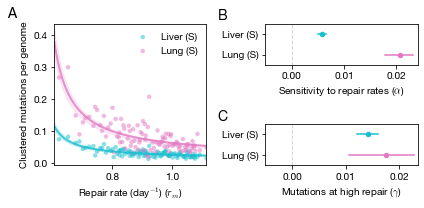

In [14]:
mosaic = '''
AB
AC
'''
fig, axs = plt.subplot_mosaic(mosaic, figsize=[6,3])

ax = axs["A"]
plot_curve(ax, "Liver_smoker", "Clusters", palette["liver"], "Liver (S)", boot_params, cis, n_indivs, s=sz, alpha=ap)
plot_curve(ax, "Lung_smoker", "Clusters", palette["lung"], "Lung (S)", boot_params, cis, n_indivs, s=sz, alpha=ap)
ax.legend(frameon=False)
ax.set_xlabel(r"Repair rate (day$^{-1}$) ($r_m$)", math_fontfamily='cm')
ax.set_ylabel("Clustered mutations per genome")

axB = axs["B"]
axC = axs["C"]

ctype_order = ["Lung (S)", "Liver (S)"]
for _,r in ab_boot[ab_boot.sig=="Clusters"].iterrows():
    y = ctype_order.index(r.ctype)
    y = y
    if r.param=="A":
        c = palette["liver"] if r.ctype=="Liver (S)" else palette["lung"]
        axB.scatter(r.point, y, color=c, s=sz)
        axB.plot((r.low, r.high), (y, y), color=c)
        if min([r.point, r.low, r.high]) < 0:
            axB.annotate("ns", xy=(r.point+0.07, y), color=c, va="center", ha="left")
    if r.param=="B":
        c = palette["liver"] if r.ctype=="Liver (S)" else palette["lung"]
        axC.scatter(r.point, y, color=c, s=sz)
        axC.plot((r.low, r.high), (y, y), color=c)
        if min([r.point, r.low, r.high]) < 0:
            axC.annotate("ns", xy=(r.point+0.14, y), color=c, va="center", ha="left")

axB.set_xlabel(r"Sensitivity to repair rates ($\alpha$)", math_fontfamily='cm')
axC.set_xlabel(r"Mutations at high repair ($\gamma$)", math_fontfamily='cm')

for let in ["B", "C"]:
    ax = axs[let]
    ax.set_ylim([-0.5,1.5])
    ax.set_xlim(left=-0.005)
    ax.axvline(x=0, color="lightgray", ls="--", lw=1)
    ax.set_yticks(range(len(ctype_order)))
    ax.set_yticklabels(ctype_order)

for label, ax_panel in axs.items():
    ax_panel.annotate(label, 
                      xy=(-0.25, 1.02), # Adjust these values to shift the letter
                      xycoords='axes fraction', 
                      fontsize=14, 
                      fontweight='bold', 
                      va='bottom', 
                      ha='right')


plt.tight_layout()
plt.savefig("sup_pdfs/clusters_alpha_gamma.pdf")